# NeurIPS Table 1: unified ID/OOD generative evaluation

Evaluate every generative model on the same ID + OOD trajectory split and produce a single comparable table:

- **VAE** (PINC)
- **VQ-VAE** (PINC, random codes from empirical codebook prior)
- **VQ-VAE + AR** (PINC, transformer over VQ codes)
- **Diff** (flow-matching) — 5D + linear probes (probe ae / probe gen)
- **GyroSwin** *(optional)* — set `GYROSWIN_CHECKPOINT = None` to skip

In [12]:
%load_ext autoreload
%autoreload 2

import os, sys
os.environ["CUDA_VISIBLE_DEVICES"] = "2"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

from pathlib import Path

PROJECT_ROOT = "/system/user/gutenbru/pl/plasmamodelling"
for _p in (PROJECT_ROOT, os.path.join(PROJECT_ROOT, "notebooks")):
    if _p not in sys.path:
        sys.path.insert(0, _p)

import torch
from neurips_generate_table1 import (
    TRAJECTORIES_ID, TRAJECTORIES_OOD, TRAJECTORIES_TEST,
    evaluate_vae, evaluate_vqvae, evaluate_ar,
    evaluate_diff, evaluate_gyroswin, evaluate_gyroswin_new,
    load_gyroswin_xxl_results,
    evaluate_reconstruction, build_recon_table, format_recon_latex,
    build_summary_table,
)


torch.use_deterministic_algorithms(False)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"CUDA_VISIBLE_DEVICES = {os.environ.get('CUDA_VISIBLE_DEVICES')!r}")
print(f"torch.cuda.device_count() = {torch.cuda.device_count()}")
print(f"DEVICE = {DEVICE}")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
CUDA_VISIBLE_DEVICES = '2'
torch.cuda.device_count() = 1
DEVICE = cuda


In [2]:
# ---- paths -----------------------------------------------------------
CKPT_ROOT           = "/restricteddata/ukaea/checkpoints/neurips26"
VAE_CKPT_DIR        = f"{CKPT_ROOT}/VAE_noCond/20260412_174027_099"
VQVAE_CKPT_DIR      = f"{CKPT_ROOT}/VQVAE_decCond/20260409_111450_134"
AR_CKPT_DIR         = f"{CKPT_ROOT}/VQVAE_AR/20260416_130636_591"
DIFF_CKPT_DIR       = f"{CKPT_ROOT}/DIFF_FLOW/20260412_180101_948"
AE_CHECKPOINT       = f"{CKPT_ROOT}/AE_noCond/20260405_022851_327/best.pth"
VQ_INDEX_PKL        = f"{CKPT_ROOT}/norm_files/diff_train_indices_offset80_mu_57f5caf20c1e_indices_vqvae134.pkl"
INFERENCE_CFG       = f"{PROJECT_ROOT}/configs/pinc_inference.yaml"
# /restricteddata has the proper OOD metadata (kyspec / fluxspec / flux);
# the older /local00 mirror was missing those keys and produced NaN OOD rows.
DATA_PREP           = Path("/restricteddata/ukaea/gyrokinetics/preprocessed_kvikio")

# Old GyroSwin (separate codebase, monkey-patched). None to skip.
GYROSWIN_CHECKPOINT = "/restricteddata/ukaea/checkpoints/scaling_law/gyroswin_xxl_fluxavg_cond_nodrop_l1"
GYROSWIN_CHECKPOINT = None

# New GyroSwin checkpoints (current codebase). One entry per checkpoint, each
# with its own start_timestep and short variant name. The variant becomes the
# row label "GyroSwin (<variant>)" in the summary table. Use [] to skip.
GYROSWIN_NEW_RUNS = [
    {
        "variant":         "warm",
        "checkpoint":      f"{CKPT_ROOT}/GyroSwin_warm/20260422_081638_223",
        "start_timestep":  80,
    },
    {
        "variant":         "cold",
        "checkpoint":      f"{CKPT_ROOT}/GyroSwin_cold/20260422_145740_594",
        "start_timestep":  0,
    },
]
# GYROSWIN_NEW_RUNS = []

# ---- knobs (shared across models) ------------------------------------
N_SAMPLES         = 128   # VAE / VQ-VAE / AR / Diff prior samples per traj
BATCH_SIZE        = 64
N_DENOISING_STEPS = 15    # diff (flow-matching) inference steps
GYROSWIN_N_STEPS  = 128   # AR rollout length

# ---- cache layout ----------------------------------------------------
# v3: caches carry _gen_time_s / _n_samples for the timing column, and the
# DATA_PREP switch fixed the OOD NaN; pre-v3 caches don't have those.
RESULTS_DIR = Path(PROJECT_ROOT) / "notebooks" / "results" / "table1"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

VAE_CACHE      = RESULTS_DIR / f"vae_n{N_SAMPLES}_v3.pt"
VQVAE_CACHE    = RESULTS_DIR / f"vqvae_n{N_SAMPLES}_v3.pt"
AR_CACHE       = RESULTS_DIR / f"ar_n{N_SAMPLES}_v3.pt"
DIFF_CACHE     = RESULTS_DIR / f"diff_n{N_SAMPLES}_steps{N_DENOISING_STEPS}_v3.pt"
GYROSWIN_CACHE = RESULTS_DIR / f"gyroswin_n{GYROSWIN_N_STEPS}_v3.pt"

# Cache filename per new-GyroSwin variant -- keyed on variant + start_timestep
# so warm/cold (and any future variants) don't collide.
def _gyroswin_new_cache_path(variant, start_timestep):
    return RESULTS_DIR / f"gyroswin_{variant}_n{GYROSWIN_N_STEPS}_t{start_timestep}_v3.pt"

all_results = {}
print("Trajectories  ID :", len(TRAJECTORIES_ID))
print("Trajectories OOD :", len(TRAJECTORIES_OOD))
print("Cache dir        :", RESULTS_DIR)

Trajectories  ID : 6
Trajectories OOD : 5
Cache dir        : /system/user/gutenbru/pl/plasmamodelling/notebooks/results/table1


In [3]:
# # ---- paths -----------------------------------------------------------
# VAE_CKPT_DIR        = "/projects/u6eb/outputs/20260415_155440_886"
# VQVAE_CKPT_DIR      = "/scratch/u6eb/fpaische.u6eb/outputs/20260409_111450_134"
# AR_CKPT_DIR         = "/projects/u6eb/outputs/20260416_130636_591"
# DIFF_CKPT_DIR       = "/projects/u6eb/outputs/20260412_180101_948/"
# AE_CHECKPOINT       = "/projects/u6eb/outputs/20260405_022851_327/best.pth"
# VQ_INDEX_PKL        = "/projects/u6eb/gyrokinetics/preprocessed_kvikio/diff_train_indices_offset80_mu_57f5caf20c1e_indices_vqvae134.pkl"
# INFERENCE_CFG       = "/home/u6eb/gutenbru.u6eb/plasmamodelling/configs/pinc_inference.yaml"
# DATA_PREP           = Path("/projects/u6eb/gyrokinetics/preprocessed_kvikio")

# # Set to None to skip the GyroSwin chapter entirely.
# # GYROSWIN_CHECKPOINT = "/projects/u6eb/checkpoints/gyroswin_xxl_fluxavg_cond_nodrop_l1"
# GYROSWIN_CHECKPOINT = None

# # ---- knobs (shared across models) ------------------------------------
# N_SAMPLES         = 128   # VAE / VQ-VAE / AR / Diff prior samples per traj
# BATCH_SIZE        = 64
# N_DENOISING_STEPS = 15    # diff (flow-matching) inference steps
# GYROSWIN_N_STEPS  = 128   # AR rollout length

# # ---- cache layout ----------------------------------------------------
# RESULTS_DIR = Path(PROJECT_ROOT) / "notebooks" / "results" / "table1"
# RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# VAE_CACHE      = RESULTS_DIR / f"vae_n{N_SAMPLES}.pt"
# VQVAE_CACHE    = RESULTS_DIR / f"vqvae_n{N_SAMPLES}.pt"
# AR_CACHE       = RESULTS_DIR / f"ar_n{N_SAMPLES}.pt"
# DIFF_CACHE     = RESULTS_DIR / f"diff_n{N_SAMPLES}_steps{N_DENOISING_STEPS}.pt"
# GYROSWIN_CACHE = RESULTS_DIR / f"gyroswin_n{GYROSWIN_N_STEPS}.pt"

# all_results = {}
# print("Trajectories  ID :", len(TRAJECTORIES_ID))
# print("Trajectories OOD :", len(TRAJECTORIES_OOD))
# print("Cache dir        :", RESULTS_DIR)

## VAE

In [4]:
all_results.update(evaluate_vae(
    VAE_CKPT_DIR, INFERENCE_CFG,
    n_samples=N_SAMPLES, batch_size=BATCH_SIZE,
    output_path=str(VAE_CACHE),
    data_path=DATA_PREP,
    device=DEVICE,
))


  VAE
  GPU before: alloc=0.00G reserved=0.00G
  [cache hit ] /system/user/gutenbru/pl/plasmamodelling/notebooks/results/table1/vae_n128_v3.pt
  GPU after:  alloc=0.00G reserved=0.00G


## VQ-VAE

In [5]:
all_results.update(evaluate_vqvae(
    VQVAE_CKPT_DIR, INFERENCE_CFG,
    vq_index_pkl=VQ_INDEX_PKL,
    n_samples=N_SAMPLES, batch_size=BATCH_SIZE,
    output_path=str(VQVAE_CACHE),
    data_path=DATA_PREP,
    device=DEVICE,
))


  VQ-VAE
  GPU before: alloc=0.00G reserved=0.00G
  [cache hit ] /system/user/gutenbru/pl/plasmamodelling/notebooks/results/table1/vqvae_n128_v3.pt
  GPU after:  alloc=0.00G reserved=0.00G


## VQ-VAE + AR

In [6]:
all_results.update(evaluate_ar(
    AR_CKPT_DIR, INFERENCE_CFG,
    ae_checkpoint=VQVAE_CKPT_DIR,  # AR cfg's ae_checkpoint is a stale HPC path
    n_samples=N_SAMPLES, batch_size=8,
    output_path=str(AR_CACHE),
    data_path=DATA_PREP,
    device=DEVICE,
))


  AR (over VQ-VAE codes)
  GPU before: alloc=0.00G reserved=0.00G
  [cache hit ] /system/user/gutenbru/pl/plasmamodelling/notebooks/results/table1/ar_n128_v3.pt
  GPU after:  alloc=0.00G reserved=0.00G


## Diff (flow-matching)

Produces both `Diff 5D` rows and the linear-probe rows (`probe (ae)` /
`probe (gen)`). Probes are fit on training latents and applied to the
per-trajectory latents that this chapter samples — no second sampling pass.

In [7]:
all_results.update(evaluate_diff(
    DIFF_CKPT_DIR, AE_CHECKPOINT,
    data_path=DATA_PREP,
    n_samples=N_SAMPLES, gen_batch_size=BATCH_SIZE,
    n_denoising_steps=N_DENOISING_STEPS,
    with_probes=True,
    output_path=str(DIFF_CACHE),
    device=DEVICE,
))


  Diff (flow-matching)
  GPU before: alloc=0.00G reserved=0.00G
  [cache hit ] /system/user/gutenbru/pl/plasmamodelling/notebooks/results/table1/diff_n128_steps15_v3.pt
  GPU after:  alloc=0.00G reserved=0.00G


## GyroSwin (optional)

Skipped if `GYROSWIN_CHECKPOINT` is `None` in the config cell.

In [11]:
if GYROSWIN_CHECKPOINT:
    all_results.update(evaluate_gyroswin(
        GYROSWIN_CHECKPOINT, DIFF_CKPT_DIR, AE_CHECKPOINT,
        data_prep=DATA_PREP,
        n_steps=GYROSWIN_N_STEPS,
        output_path=str(GYROSWIN_CACHE),
        device=DEVICE,
    ))
else:
    print("GYROSWIN_CHECKPOINT is None  ->  skipping GyroSwin chapter.")

GYROSWIN_CHECKPOINT is None  ->  skipping GyroSwin chapter.


## GyroSwin (new, current-codebase checkpoints)

Loaded the same way as the other generative models (no monkey-patching).
One entry per checkpoint in `GYROSWIN_NEW_RUNS`; each gets its own
`start_timestep` (0 = initial condition, 80 = the offset used during
training) and `variant` short-name. Each variant becomes a row labeled
`GyroSwin (<variant>)` in the summary table.

Skipped if `GYROSWIN_NEW_RUNS` is empty.

In [18]:
if GYROSWIN_NEW_RUNS:
    for run in GYROSWIN_NEW_RUNS:
        all_results.update(evaluate_gyroswin_new(
            run["checkpoint"],
            data_path=DATA_PREP,
            variant=run["variant"],
            n_steps=GYROSWIN_N_STEPS,
            start_timestep=run["start_timestep"],
            output_path=str(_gyroswin_new_cache_path(
                run["variant"], run["start_timestep"],
            )),
            device=DEVICE,
        ))
else:
    print("GYROSWIN_NEW_RUNS is empty  ->  skipping new GyroSwin chapter.")


  GyroSwin (warm, AR rollout)
  GPU before: alloc=0.01G reserved=4.30G
  [cache hit ] /system/user/gutenbru/pl/plasmamodelling/notebooks/results/table1/gyroswin_warm_n128_t80_v3.pt
  GPU after:  alloc=0.01G reserved=4.30G

  GyroSwin (cold, AR rollout)
  GPU before: alloc=0.01G reserved=4.30G
  [cache hit ] /system/user/gutenbru/pl/plasmamodelling/notebooks/results/table1/gyroswin_cold_n128_t0_v3.pt
  GPU after:  alloc=0.01G reserved=4.30G


## GyroSwin XXL (load cached AR rollouts from disk)

Reads the pre-computed per-step outputs under
`gyroswin_xxl_*/autoreg_t0/<traj>/best/K{step}/` (eflux scalar, kyspec (32,),
eflux_spectra (32,)) and pairs them with GT references pulled from
`metadata.pkl`. No model load required.

Trajectories without a matching dump are skipped automatically. `kxspec`
isn't dumped, so that column comes out NaN for this row. Set
`GYROSWIN_XXL_AUTOREG = None` to skip.

In [13]:
GYROSWIN_XXL_AUTOREG = "/restricteddata/ukaea/checkpoints/scaling_law/gyroswin_xxl_fluxavg_cond_nodrop_l1/autoreg_t0"
# GYROSWIN_XXL_AUTOREG = None

if GYROSWIN_XXL_AUTOREG:
    all_results.update(load_gyroswin_xxl_results(
        GYROSWIN_XXL_AUTOREG,
        data_path=DATA_PREP,
        n_last_steps=80,
    ))
else:
    print("GYROSWIN_XXL_AUTOREG is None  ->  skipping cached GyroSwin XXL chapter.")


  GyroSwin XXL (load cached AR rollouts)
  [gyroswin_xxl_id] iteration_262_ifft_realpotens: n_steps=80/184 (last-80), pred eflux mean=126.9, gt eflux mean=147.3
  [gyroswin_xxl_id] iteration_131_ifft_realpotens: n_steps=80/184 (last-80), pred eflux mean=97.02, gt eflux mean=141.6  [meta key='fluxes']
  [gyroswin_xxl_id] iteration_8_ifft_realpotens: n_steps=80/184 (last-80), pred eflux mean=125.8, gt eflux mean=148.6
  [gyroswin_xxl_id] iteration_235_ifft_realpotens: n_steps=80/184 (last-80), pred eflux mean=119.2, gt eflux mean=113.9
  [gyroswin_xxl_id] iteration_148_ifft_realpotens: n_steps=80/184 (last-80), pred eflux mean=59.98, gt eflux mean=70.69
  [gyroswin_xxl_id] iteration_115_ifft_realpotens: n_steps=80/184 (last-80), pred eflux mean=56.5, gt eflux mean=74.16
  [gyroswin_xxl_ood] ood_iteration_0_ifft_realpotens: n_steps=80/184 (last-80), pred eflux mean=65.62, gt eflux mean=66.47
  [gyroswin_xxl_ood] ood_iteration_1_ifft_realpotens: n_steps=80/184 (last-80), pred eflux mean=1

## Summary table

Single row per (model, split). Columns: eflux_RMSE, kxspec_RMSE,
kyspec_RMSE, fluxspec_RMSE. All entries computed via the same
`print_aggregate_metrics` formula.

In [ ]:
summary = build_summary_table(all_results, with_diff_probes=True)
print(summary.to_string(float_format=lambda x: f"{x:.4g}"))
summary

                        eflux_RMSE  eflux_RMSE_std  kxspec_RMSE  kxspec_RMSE_std  kxspec_WD  kxspec_WD_std  kyspec_RMSE  kyspec_RMSE_std  kyspec_WD  kyspec_WD_std  fluxspec_RMSE  fluxspec_RMSE_std  time_per_sample_s
model            split                                                                                                                                                                                                 
VAE              ID          106.3            32.3     1.91e+05        1.741e+05   0.008893       0.003211    4.214e+05        3.843e+05    0.01386        0.01011          13.84              5.874             0.0189
                 OOD         112.8           44.07    5.228e+05        4.473e+05    0.01174        0.00389    1.125e+06        9.569e+05     0.0159       0.004706          14.07              7.398            0.01818
VQ-VAE           ID          74.78           29.96    4.266e+04        3.786e+04   0.007036       0.004452    9.098e+04        7.979e+04

eflux_RMSE  eflux_RMSE_std   kxspec_RMSE  \
model            split                                             
VAE              ID     106.313416       32.299314  1.910165e+05   
                 OOD    112.832344       44.069063  5.227871e+05   
VQ-VAE           ID      74.778564       29.962016  4.266073e+04   
                 OOD     72.466606       32.247912  1.124327e+05   
AR               ID      52.992470       24.117723  3.853127e+04   
                 OOD     45.306095       22.819544  1.249552e+05   
Diff 5D          ID      14.364942        9.408355  2.312755e+05   
                 OOD     16.382229        7.061288  1.618292e+06   
Diff probe (ae)  ID      21.609428       11.118310  7.435213e+03   
                 OOD     25.189125       15.356004  2.641834e+03   
Diff probe (gen) ID      14.399563       10.314553  6.552123e+03   
                 OOD     17.430847       11.803342  2.499868e+03   
GyroSwin XXL     ID      23.746698       13.577810           NaN   
                 OOD     26.148972       21.092836           NaN   
GyroSwin (cold)  ID      30.373335       19.114820  1.181655e+06   
                 OOD     33.145767       22.663654  1.482623e+07   
GyroSwin (warm)  ID      39.378201       28.977988  3.441008e+05   
                 OOD     19.455240        6.219283  6.863359e+05   

                        kxspec_RMSE_std  kxspec_WD  kxspec_WD_std  \
model            split                                              
VAE              ID        1.741121e+05   0.008893       0.003211   
                 OOD       4.473305e+05   0.011739       0.003890   
VQ-VAE           ID        3.785889e+04   0.007036       0.004452   
                 OOD       1.040698e+05   0.010231       0.004556   
AR               ID        3.407044e+04   0.006467       0.004811   
                 OOD       1.175533e+05   0.009734       0.004912   
Diff 5D          ID        1.920938e+05   0.007832       0.004446   
                 OOD       1.522086e+06   0.011232       0.004121   
Diff probe (ae)  ID        5.443794e+03   0.004585       0.002652   
                 OOD       1.870096e+03   0.004447       0.002376   
Diff probe (gen) ID        4.900285e+03   0.004220       0.002281   
                 OOD       1.400723e+03   0.006178       0.003067   
GyroSwin XXL     ID                 NaN        NaN            NaN   
                 OOD                NaN        NaN            NaN   
GyroSwin (cold)  ID        1.092038e+06   0.010352       0.004578   
                 OOD       1.452069e+07   0.012680       0.003404   
GyroSwin (warm)  ID        3.270647e+05   0.010264       0.003349   
                 OOD       6.302025e+05   0.011744       0.003907   

                         kyspec_RMSE  kyspec_RMSE_std  kyspec_WD  \
model            split                                             
VAE              ID     4.214300e+05     3.843014e+05   0.013860   
                 OOD    1.125000e+06     9.569194e+05   0.015901   
VQ-VAE           ID     9.097573e+04     7.978680e+04   0.012578   
                 OOD    2.715863e+05     2.514563e+05   0.014853   
AR               ID     8.231375e+04     7.216348e+04   0.010492   
                 OOD    3.124013e+05     2.949671e+05   0.013117   
Diff 5D          ID     5.159621e+05     4.301102e+05   0.012288   
                 OOD    3.605397e+06     3.390638e+06   0.014879   
Diff probe (ae)  ID     2.233301e+03     1.638596e+03   0.013407   
                 OOD    7.710336e+02     4.747302e+02   0.011195   
Diff probe (gen) ID     2.142977e+03     1.645564e+03   0.009307   
                 OOD    6.161920e+02     4.665871e+02   0.008312   
GyroSwin XXL     ID     2.123698e+05     1.856443e+05   0.010067   
                 OOD    3.628989e+06     3.615866e+06   0.014019   
GyroSwin (cold)  ID     2.675401e+06     2.469455e+06   0.014465   
                 OOD    3.506588e+07     3.436088e+07   0.016191   
GyroSwin (warm)  ID     6.775095e+05     6.448777e+05   0.

In [20]:
s1 = summary[["eflux_RMSE", "eflux_RMSE_std", "kyspec_WD", "kyspec_WD_std", "fluxspec_RMSE", "fluxspec_RMSE_std", "time_per_sample_s"]]
print(s1.to_string(float_format=lambda x: f"{x:.4g}"))
s1


                        eflux_RMSE  eflux_RMSE_std  kyspec_WD  kyspec_WD_std  fluxspec_RMSE  fluxspec_RMSE_std  time_per_sample_s
model            split                                                                                                           
VAE              ID          106.3            32.3    0.01386        0.01011          13.84              5.874             0.0189
                 OOD         112.8           44.07     0.0159       0.004706          14.07              7.398            0.01818
VQ-VAE           ID          74.78           29.96    0.01258       0.009217          12.94              6.071             0.0219
                 OOD         72.47           32.25    0.01485       0.004726           12.7              7.222            0.01871
AR               ID          52.99           24.12    0.01049       0.008007          9.936              5.065             0.1326
                 OOD         45.31           22.82    0.01312       0.005658          8.31

eflux_RMSE  eflux_RMSE_std  kyspec_WD  kyspec_WD_std  \
model            split                                                         
VAE              ID     106.313416       32.299314   0.013860       0.010107   
                 OOD    112.832344       44.069063   0.015901       0.004706   
VQ-VAE           ID      74.778564       29.962016   0.012578       0.009217   
                 OOD     72.466606       32.247912   0.014853       0.004726   
AR               ID      52.992470       24.117723   0.010492       0.008007   
                 OOD     45.306095       22.819544   0.013117       0.005658   
Diff 5D          ID      14.364942        9.408355   0.012288       0.010378   
                 OOD     16.382229        7.061288   0.014879       0.005022   
Diff probe (ae)  ID      21.609428       11.118310   0.013407       0.002682   
                 OOD     25.189125       15.356004   0.011195       0.002186   
Diff probe (gen) ID      14.399563       10.314553   0.009307       0.003455   
                 OOD     17.430847       11.803342   0.008312       0.003187   
GyroSwin XXL     ID      23.746698       13.577810   0.010067       0.007552   
                 OOD     26.148972       21.092836   0.014019       0.006140   
GyroSwin (cold)  ID      30.373335       19.114820   0.014465       0.010339   
                 OOD     33.145767       22.663654   0.016191       0.004292   
GyroSwin (warm)  ID      39.378201       28.977988   0.012641       0.009824   
                 OOD     19.455240        6.219283   0.015083       0.004977   

                        fluxspec_RMSE  fluxspec_RMSE_std  time_per_sample_s  
model            split                                                       
VAE              ID         13.842305           5.873979           0.018899  
                 OOD        14.066314           7.397548           0.018179  
VQ-VAE           ID         12.939632           6.071347           0.021900  
                 OOD        12.701621           7.221667           0.018713  
AR               ID          9.935530           5.065459           0.132593  
                 OOD         8.311367           5.080918           0.131050  
Diff 5D          ID          3.366056           1.536576           0.035576  
                 OOD         6.747580           3.496291           0.035660  
Diff probe (ae)  ID         12.593287           6.155071           0.018533  
                 OOD        12.857918           7.726445           0.018605  
Diff probe (gen) ID         12.156989           6.159943           0.018533  
                 OOD        12.341827           7.919896           0.018605  
GyroSwin XXL     ID          9.278101           6.326562                NaN  
                 OOD        10.530515           6.341124                NaN  
GyroSwin (cold)  ID         13.600214           5.819528          17.813262  
                 OOD        13.867866           7.707975          17.727923  
GyroSwin (warm)  ID         13.100807           7.462063          17.230767  
                 OOD        11.883823           7.099604          17.062900

## Reconstruction error (AE / VAE / VQ-VAE)

For each ID + OOD trajectory, runs every post-offset df binary through the
model (encode + decode, eval mode) and computes RMSEs for both:
- `df_RMSE` — point-wise reconstruction RMSE on the distribution function in
  *physical* (denormalized) space.
- `eflux_RMSE`, `kxspec_RMSE`, `kyspec_RMSE`, `fluxspec_RMSE` (= `qspec`) —
  RMSE on the physics integrals (`FluxIntegral(flux_fields=True,
  spectral_df=False, spectral_potens=True)`) computed from the reconstructed
  vs. ground-truth df. Same integrator and column names as the summary table
  above, so the rows are directly comparable.

Per-trajectory RMSE = `sqrt(mean((pred - target)^2))` over all timesteps and
spatial dims for each quantity. The columns below show mean ± sample std
(ddof=1) of those per-traj RMSEs across the trajectories in each split.

`params_M` is the total parameter count of each model in millions.


In [4]:
RECON_BATCH_SIZE = 4

# AE checkpoint here is a path to best.pth -- evaluate_reconstruction takes the
# directory, so strip the trailing filename.
recon_results = {}
recon_results["AE"] = evaluate_reconstruction(
    os.path.dirname(AE_CHECKPOINT), INFERENCE_CFG,
    data_path=DATA_PREP, batch_size=RECON_BATCH_SIZE, device=DEVICE,
)
recon_results["VAE"] = evaluate_reconstruction(
    VAE_CKPT_DIR, INFERENCE_CFG,
    data_path=DATA_PREP, batch_size=RECON_BATCH_SIZE, device=DEVICE,
)
recon_results["VQ-VAE"] = evaluate_reconstruction(
    VQVAE_CKPT_DIR, INFERENCE_CFG,
    data_path=DATA_PREP, batch_size=RECON_BATCH_SIZE, device=DEVICE,
)


  Reconstruction
  ckpt_dir=/restricteddata/ukaea/checkpoints/neurips26/AE_noCond/20260405_022851_327
  GPU before: alloc=0.00G reserved=0.00G
  building trainset (/restricteddata/ukaea/checkpoints/neurips26/AE_noCond/20260405_022851_327) ...
Loading ['df', 'phi', 'flux'] in dataset
    metadata: 289 files in 124.1s (lightweight=True)
loading pre-computed stats from /restricteddata/ukaea/gyrokinetics/preprocessed_kvikio/diff_df_flux_phi_offset80_mu_57f5caf2_stats.pkl
No aggregations for flux, using stats of shape: (1,)
    metadata: 3 files in 4.0s (lightweight=True)
Train: 44400
Holdout trajectories (val): 555
Validation ratio: 0.01
  loading AE weights ...


/system/apps/userenv/galletti/mhd/bin/../lib/gcc/x86_64-conda-linux-gnu/11.2.0/../../../../x86_64-conda-linux-gnu/bin/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
/system/apps/userenv/galletti/mhd/bin/../lib/gcc/x86_64-conda-linux-gnu/11.2.0/../../../../x86_64-conda-linux-gnu/bin/ld: cannot find -lcufile: No such file or directory
collect2: error: ld returned 1 exit status


AE parameters: 217.6M
Compression: 604.4x (type: ae). (32, *[32, 16, 85, 32]) -> (256, *[4, 2, 9, 4])
Loading model /restricteddata/ukaea/checkpoints/neurips26/AE_noCond/20260405_022851_327/best.pth (stopped at epoch 400) 


  ood_iteration_4_ifft_realpotens: 100%|██████████| 47/47 [02:26<00:00,  3.11s/batch]


  GPU after:  alloc=0.01G reserved=0.04G

  Reconstruction
  ckpt_dir=/restricteddata/ukaea/checkpoints/neurips26/VAE_noCond/20260412_174027_099
  GPU before: alloc=0.01G reserved=0.04G
  building trainset (/restricteddata/ukaea/checkpoints/neurips26/VAE_noCond/20260412_174027_099) ...
Loading ['df', 'phi', 'flux'] in dataset
    metadata: 289 files in 5.0s (lightweight=True)
loading pre-computed stats from /restricteddata/ukaea/gyrokinetics/preprocessed_kvikio/diff_df_flux_phi_offset80_mu_57f5caf2_stats.pkl
No aggregations for flux, using stats of shape: (1,)
    metadata: 6 files in 0.2s (lightweight=True)
Train: 44400
Holdout trajectories (val): 1110
Validation ratio: 0.03
  loading AE weights ...
VAE parameters: 217.9M
Compression: 604.4x (type: vae). (32, *[32, 16, 85, 32]) -> (256, *[4, 2, 9, 4])
Loading model /restricteddata/ukaea/checkpoints/neurips26/VAE_noCond/20260412_174027_099/best.pth (stopped at epoch 400) 


  ood_iteration_4_ifft_realpotens: 100%|██████████| 47/47 [00:40<00:00,  1.15batch/s]


  GPU after:  alloc=0.01G reserved=0.04G

  Reconstruction
  ckpt_dir=/restricteddata/ukaea/checkpoints/neurips26/VQVAE_decCond/20260409_111450_134
  GPU before: alloc=0.01G reserved=0.04G
  building trainset (/restricteddata/ukaea/checkpoints/neurips26/VQVAE_decCond/20260409_111450_134) ...
Loading ['df', 'phi', 'flux'] in dataset
    metadata: 289 files in 5.0s (lightweight=True)
loading pre-computed stats from /restricteddata/ukaea/gyrokinetics/preprocessed_kvikio/diff_df_flux_phi_offset80_mu_57f5caf2_stats.pkl
No aggregations for flux, using stats of shape: (1,)
    metadata: 3 files in 0.1s (lightweight=True)
Train: 44400
Holdout trajectories (val): 555
Validation ratio: 0.01
  loading AE weights ...
VQ-VAE parameters: 225.8M
Compression: 95223.2x (type: vqvae). (32, *[32, 16, 85, 32]) -> (256, *[4, 2, 9, 4])
Loading model /restricteddata/ukaea/checkpoints/neurips26/VQVAE_decCond/20260409_111450_134/best.pth (stopped at epoch 400) 


  ood_iteration_4_ifft_realpotens: 100%|██████████| 47/47 [00:41<00:00,  1.14batch/s]


  GPU after:  alloc=0.01G reserved=0.04G


In [5]:
recon_table = build_recon_table(recon_results)
print(recon_table.to_string(float_format=lambda x: f"{x:.4g}"))
recon_table

        params_M  recon_RMSE_id  recon_RMSE_id_std  recon_RMSE_ood  recon_RMSE_ood_std
model                                                                                 
AE         217.6         0.7533             0.1748          0.7865              0.2567
VAE        217.9         0.8384             0.1708          0.8687              0.2488
VQ-VAE     225.8         0.8876             0.1874          0.9239               0.273


,params_M,recon_RMSE_id,recon_RMSE_id_std,recon_RMSE_ood,recon_RMSE_ood_std
model,,,,,
AE,217.632352,0.753256,0.174764,0.786465,0.256739
VAE,217.894752,0.838354,0.170771,0.868723,0.248822
VQ-VAE,225.826528,0.887592,0.187439,0.923898,0.273011


In [ ]:
# Single-column df-only table (matches the original template)
print(format_recon_latex(recon_results, quantities=["df"]))

# Combined table: df + Q-spec + k_y-spec (3 quantities, 8 columns)
print(format_recon_latex(
    recon_results,
    quantities=["df", "eflux", "kyspec", "qspec"], #["df", "eflux", "kxspec", "kyspec", "qspec"]
    label="tab:ae_recon_combined",
))


## Ablation: number of Euler sampling steps (N)

Sweep `N_DENOISING_STEPS` for the flow-matching diffusion model on ID
trajectories only. Reports Diff 5D's $\bar Q$ (eflux) RMSE and wall-clock
time per sample as a function of $N$. Inference default is $N=15$; smaller
$N$ is cheaper but is expected to hurt RMSE.


  Diff (flow-matching, N sweep over [1, 2, 4, 7, 15, 20, 30, 50])
  GPU before: alloc=0.01G reserved=0.02G
  [cache hit ] N=1: /system/user/gutenbru/pl/plasmamodelling/notebooks/results/table1/diff_n128_steps1_idood_v3.pt
  [cache hit ] N=2: /system/user/gutenbru/pl/plasmamodelling/notebooks/results/table1/diff_n128_steps2_idood_v3.pt
  [cache hit ] N=4: /system/user/gutenbru/pl/plasmamodelling/notebooks/results/table1/diff_n128_steps4_idood_v3.pt
  [cache hit ] N=7: /system/user/gutenbru/pl/plasmamodelling/notebooks/results/table1/diff_n128_steps7_idood_v3.pt
  [cache hit ] N=15: /system/user/gutenbru/pl/plasmamodelling/notebooks/results/table1/diff_n128_steps15_v3.pt
  [cache hit ] N=20: /system/user/gutenbru/pl/plasmamodelling/notebooks/results/table1/diff_n128_steps20_idood_v3.pt
  [cache hit ] N=30: /system/user/gutenbru/pl/plasmamodelling/notebooks/results/table1/diff_n128_steps30_idood_v3.pt
  [cache hit ] N=50: /system/user/gutenbru/pl/plasmamodelling/notebooks/results/table1/

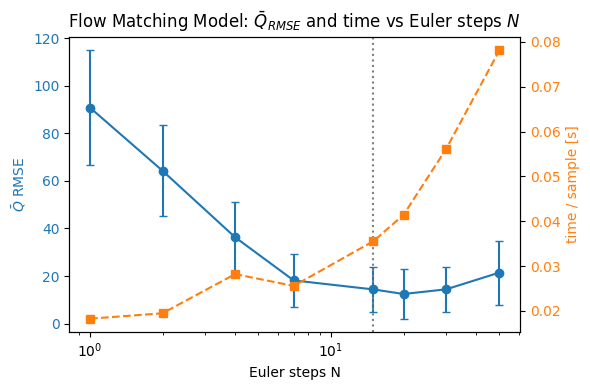

,eflux_RMSE,eflux_RMSE_std,time_per_sample_s
N,,,
1,90.829765,24.136048,0.018283
2,64.267723,19.065997,0.019495
4,36.319595,15.009937,0.028227
7,18.163797,10.993678,0.025592
15,14.364942,9.408355,0.035576
20,12.452605,10.392817,0.041454
30,14.400913,9.462231,0.056097
50,21.462883,13.470353,0.078165


In [22]:
import matplotlib.pyplot as plt
import pandas as pd
from neurips_generate_table1 import evaluate_diff_n_sweep

N_VALUES = [1, 2, 4, 7, 15, 20, 30, 50]

def _diff_n_cache(n):
    # N=15 reuses the canonical ID+OOD cache; other N values get their own
    # ID+OOD namespace so they don't half-fill the main cache.
    if n == N_DENOISING_STEPS:
        return DIFF_CACHE
    return RESULTS_DIR / f"diff_n{N_SAMPLES}_steps{n}_idood_v3.pt"

# Build the diffusion runner ONCE and sweep N over N_VALUES. Per-N caches are
# loaded directly when present; pending N's reuse the same loaded model.
n_sweep = evaluate_diff_n_sweep(
    DIFF_CKPT_DIR, AE_CHECKPOINT,
    data_path=DATA_PREP,
    n_denoising_steps_list=N_VALUES,
    n_samples=N_SAMPLES, gen_batch_size=BATCH_SIZE,
    output_path_fn=lambda n: str(_diff_n_cache(n)),
    trajectories_test=TRAJECTORIES_TEST,
    device=DEVICE,
)

ablation_rows = []
for n in N_VALUES:
    res = n_sweep[n]
    row = build_summary_table({"diff_id": res["diff_id"]},
                              with_diff_probes=False).iloc[0]
    ablation_rows.append({
        "N":                 n,
        "eflux_RMSE":        float(row["eflux_RMSE"]),
        "eflux_RMSE_std":    float(row["eflux_RMSE_std"]),
        "time_per_sample_s": float(row["time_per_sample_s"]),
    })

ablation_df = pd.DataFrame(ablation_rows).set_index("N")
print(ablation_df.to_string(float_format=lambda x: f"{x:.4g}"))

fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(ablation_df.index, ablation_df["eflux_RMSE"],
            yerr=ablation_df["eflux_RMSE_std"],
            marker="o", color="C0", capsize=3, label=r"$\bar Q$ RMSE")
ax.axvline(N_DENOISING_STEPS, color="grey", linestyle=":",
           label=f"default N={N_DENOISING_STEPS}")
ax.set_xscale("log")
ax.set_xlabel("Euler steps N")
ax.set_ylabel(r"$\bar Q$ RMSE", color="C0")
ax.tick_params(axis="y", labelcolor="C0")
ax2 = ax.twinx()
ax2.plot(ablation_df.index, ablation_df["time_per_sample_s"],
         marker="s", color="C1", linestyle="--")
ax2.set_ylabel("time / sample [s]", color="C1")
ax2.tick_params(axis="y", labelcolor="C1")
ax.set_title(r"Flow Matching Model: $\bar Q_{RMSE}$ and time vs Euler steps $N$")
fig.tight_layout()
plt.show()
ablation_df